In [1]:
# Section 1 — Imports + Load Both Checkpoints

from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import roc_auc_score, roc_curve

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Paths
PROJECT_ROOT = Path('..').resolve()
DATA_DIR = PROJECT_ROOT / 'data'
CHECKPOINTS_DIR = PROJECT_ROOT / 'checkpoints'

X_TRAIN_PICKLE = DATA_DIR / 'x_train.pkl'
KAGGLE_TRAIN_CSV = DATA_DIR / 'train.csv'
STAGE1_CHECKPOINT = CHECKPOINTS_DIR / 'stage1_reader_imagination.pt'
STAGE2_CHECKPOINT = CHECKPOINTS_DIR / 'stage2_concept_block.pt'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Dimensions
INPUT_DIM = 13
LATENT_DIM = 32
CONCEPT_DIM = 6

FEATURE_NAMES = [
    'lap_time_norm', 'lap_time_delta', 'cumulative_degradation',
    'tyre_life_norm', 'compound_soft', 'compound_medium', 'compound_hard',
    'compound_inter', 'compound_wet', 'position_norm', 'position_change_norm',
    'race_progress', 'stint_norm',
]
CONCEPT_NAMES = [
    'degradation_severity', 'pace_decay_rate', 'strategic_window',
    'track_position_risk', 'undercut_pressure', 'endgame_proximity',
]


# ── Re-define model classes
class Reader(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, latent_dim=LATENT_DIM):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, latent_dim)
        self.ln1 = nn.LayerNorm(latent_dim)
        self.fc2 = nn.Linear(latent_dim, latent_dim)
        self.ln2 = nn.LayerNorm(latent_dim)
        self.fc3 = nn.Linear(latent_dim, latent_dim)
    def forward(self, x):
        h = F.relu(self.ln1(self.fc1(x)))
        h = F.relu(self.ln2(self.fc2(h)))
        return self.fc3(h)


class ConceptBlock(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, concept_dim=CONCEPT_DIM, hidden_dim=16):
        super().__init__()
        self.fc1 = nn.Linear(latent_dim, hidden_dim)
        self.ln1 = nn.LayerNorm(hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, concept_dim)
    def forward(self, z):
        h = F.relu(self.ln1(self.fc1(z)))
        return torch.sigmoid(self.fc2(h))


class DecisionBlock(nn.Module):
    def __init__(self, concept_dim=CONCEPT_DIM):
        super().__init__()
        self.linear = nn.Linear(concept_dim, 1)
    def forward(self, c):
        logit = self.linear(c).squeeze(-1)
        pit_prob = torch.sigmoid(logit)
        return pit_prob, logit
    def per_concept_contributions(self, c):
        weight = self.linear.weight
        bias = self.linear.bias
        contributions = c * weight
        return contributions, bias.item()


# ── Load Stage 1 checkpoint → Reader
print("=" * 70)
print("LOADING CHECKPOINTS")
print("=" * 70)

ckpt1 = torch.load(STAGE1_CHECKPOINT, weights_only=False)
reader = Reader().to(DEVICE)
reader.load_state_dict(ckpt1['reader_state_dict'])
for p in reader.parameters():
    p.requires_grad = False
reader.eval()
print(f"\n  Reader loaded from Stage 1 (best epoch {ckpt1['best_epoch']}, val_recon={ckpt1['best_val_recon']:.5f})")
print(f"  Reader frozen: {sum(p.numel() for p in reader.parameters()):,} params, none trainable")

# ── Load Stage 2 checkpoint → ConceptBlock
ckpt2 = torch.load(STAGE2_CHECKPOINT, weights_only=False)
concept_block = ConceptBlock().to(DEVICE)
concept_block.load_state_dict(ckpt2['concept_block_state_dict'])
for p in concept_block.parameters():
    p.requires_grad = False
concept_block.eval()
print(f"\n  ConceptBlock loaded from Stage 2 (best epoch {ckpt2['best_epoch']}, val_mse={ckpt2['best_val_mse']:.5f})")
print(f"  ConceptBlock frozen: {sum(p.numel() for p in concept_block.parameters()):,} params, none trainable")


# ── Smoke test: full inference pipeline (Reader → ConceptBlock) on a tiny batch
print("\n" + "=" * 70)
print("SMOKE TEST: Reader + ConceptBlock pipeline")
print("=" * 70)
x_random = torch.randn(4, INPUT_DIM).to(DEVICE)
with torch.no_grad():
    z = reader(x_random)
    c = concept_block(z)
print(f"\n  Input x:  {tuple(x_random.shape)}")
print(f"  Output z: {tuple(z.shape)}  (mean={z.mean().item():.3f}, std={z.std().item():.3f})")
print(f"  Output c: {tuple(c.shape)}  (mean={c.mean().item():.3f}, range [{c.min().item():.3f}, {c.max().item():.3f}])")
print(f"  All concepts in [0, 1]? {((c >= 0) & (c <= 1)).all().item()}")

LOADING CHECKPOINTS

  Reader loaded from Stage 1 (best epoch 7, val_recon=0.20416)
  Reader frozen: 2,688 params, none trainable

  ConceptBlock loaded from Stage 2 (best epoch 15, val_mse=0.02273)
  ConceptBlock frozen: 662 params, none trainable

SMOKE TEST: Reader + ConceptBlock pipeline

  Input x:  (4, 13)
  Output z: (4, 32)  (mean=-0.079, std=0.819)
  Output c: (4, 6)  (mean=0.295, range [0.000, 0.981])
  All concepts in [0, 1]? True


In [2]:
# Section 2 — Build Stage 3 Dataset (Precompute Concepts on Kaggle Train)

print("=" * 70)
print("BUILDING STAGE 3 DATASET")
print("=" * 70)

# Load Kaggle train data
x_train_df = pd.read_pickle(X_TRAIN_PICKLE)
x_cols = [f'x_{n}' for n in FEATURE_NAMES]
x_train_arr = x_train_df[x_cols].values.astype(np.float32)
pit_train_arr = x_train_df['PitNextLap'].values.astype(np.int64)
print(f"  Kaggle train shape:  {x_train_df.shape}")
print(f"  PitNextLap rate:     {pit_train_arr.mean()*100:.2f}%")


# ── Precompute predicted concepts c through frozen Reader + ConceptBlock
print("\nPrecomputing predicted concepts c through frozen Reader + ConceptBlock...")
t_start = time.time()

with torch.no_grad():
    chunk_size = 50000
    c_chunks = []
    x_tensor = torch.from_numpy(x_train_arr).to(DEVICE)
    for i in range(0, len(x_tensor), chunk_size):
        chunk = x_tensor[i:i+chunk_size]
        z_chunk = reader(chunk)
        c_chunk = concept_block(z_chunk).cpu().numpy()
        c_chunks.append(c_chunk)
    c_train_pred = np.concatenate(c_chunks, axis=0)

print(f"  c_train_pred shape: {c_train_pred.shape}  ({time.time()-t_start:.1f}s)")


# ── Sanity check the predicted concepts
print("\n" + "=" * 70)
print("PREDICTED CONCEPT STATISTICS (full Kaggle train)")
print("=" * 70)

print(f"\n{'concept':<24s} | {'mean':>8s} | {'std':>8s} | {'min':>8s} | {'max':>8s} | {'frac>0.5':>10s}")
print("-" * 80)
for j, name in enumerate(CONCEPT_NAMES):
    v = c_train_pred[:, j]
    print(f"  {name:<22s} | {v.mean():>8.4f} | {v.std():>8.4f} | {v.min():>8.4f} | {v.max():>8.4f} | {(v > 0.5).mean()*100:>9.1f}%")

# Verify class separation in predicted concepts (this is critical)
print("\n" + "=" * 70)
print("CLASS SEPARATION OF PREDICTED CONCEPTS")
print("=" * 70)
print(f"\n{'concept':<24s} | {'pred|pit=0':>11s} | {'pred|pit=1':>11s} | {'difference':>11s}")
print("-" * 70)
for j, name in enumerate(CONCEPT_NAMES):
    mean_no_pit = c_train_pred[pit_train_arr == 0, j].mean()
    mean_pit = c_train_pred[pit_train_arr == 1, j].mean()
    diff = mean_pit - mean_no_pit
    arrow = "↑" if diff > 0.01 else ("↓" if diff < -0.01 else "—")
    print(f"  {name:<22s} | {mean_no_pit:>11.4f} | {mean_pit:>11.4f} | {diff:>+10.4f} {arrow}")


# ── Class imbalance check
print("\n" + "=" * 70)
print("CLASS IMBALANCE CHECK")
print("=" * 70)
n_neg = (pit_train_arr == 0).sum()
n_pos = (pit_train_arr == 1).sum()
pos_weight = n_neg / n_pos
print(f"\n  Negatives (PitNextLap=0): {n_neg:,} ({n_neg/len(pit_train_arr)*100:.2f}%)")
print(f"  Positives (PitNextLap=1): {n_pos:,} ({n_pos/len(pit_train_arr)*100:.2f}%)")
print(f"  pos_weight = #neg / #pos = {pos_weight:.3f}")
print(f"\n  This weight will be passed to BCEWithLogitsLoss to upweight positive examples.")

BUILDING STAGE 3 DATASET
  Kaggle train shape:  (439140, 21)
  PitNextLap rate:     19.90%

Precomputing predicted concepts c through frozen Reader + ConceptBlock...
  c_train_pred shape: (439140, 6)  (0.5s)

PREDICTED CONCEPT STATISTICS (full Kaggle train)

concept                  |     mean |      std |      min |      max |   frac>0.5
--------------------------------------------------------------------------------
  degradation_severity   |   0.2144 |   0.2762 |   0.0001 |   0.9978 |      16.8%
  pace_decay_rate        |   0.1783 |   0.2387 |   0.0002 |   0.9967 |      17.0%
  strategic_window       |   0.1145 |   0.1887 |   0.0000 |   0.8974 |       7.6%
  track_position_risk    |   0.3926 |   0.2981 |   0.0003 |   0.9992 |      36.4%
  undercut_pressure      |   0.1615 |   0.3031 |   0.0000 |   0.9991 |      14.9%
  endgame_proximity      |   0.0225 |   0.0876 |   0.0000 |   0.9334 |       1.1%

CLASS SEPARATION OF PREDICTED CONCEPTS

concept                  |  pred|pit=0 |  pre

In [4]:
# Section 3 — Train/Val Split + Stage 3 Training

print("=" * 70)
print("TRAIN/VAL SPLIT BY (Race, Year)")
print("=" * 70)

# Read Race/Year info from CSV (already loaded? Let's re-read to be safe)
kaggle_train_raw = pd.read_csv(KAGGLE_TRAIN_CSV)
kaggle_train_raw.columns = kaggle_train_raw.columns.str.strip()
assert (kaggle_train_raw['id'].values == x_train_df['id'].values).all(), "id mismatch"

race_year = kaggle_train_raw['Race'].astype(str) + '_' + kaggle_train_raw['Year'].astype(str)
unique_combos = race_year.unique()
print(f"  Unique (Race, Year) combos: {len(unique_combos)}")

rng = np.random.RandomState(SEED)
shuffled = rng.permutation(len(unique_combos))
n_val = int(0.2 * len(unique_combos))
val_combos = set(unique_combos[shuffled[:n_val]])
train_combos = set(unique_combos[shuffled[n_val:]])

train_mask = race_year.isin(train_combos).values
val_mask = race_year.isin(val_combos).values

print(f"  Train: {train_mask.sum():,} rows  Val: {val_mask.sum():,} rows")
print(f"  Train pit rate: {pit_train_arr[train_mask].mean()*100:.2f}%")
print(f"  Val pit rate:   {pit_train_arr[val_mask].mean()*100:.2f}%")

# Build tensors
c_train_t = torch.from_numpy(c_train_pred[train_mask])
pit_train_t = torch.from_numpy(pit_train_arr[train_mask]).float()
c_val_t = torch.from_numpy(c_train_pred[val_mask])
pit_val_t = torch.from_numpy(pit_train_arr[val_mask]).float()

BATCH_SIZE = 256
train_loader = DataLoader(TensorDataset(c_train_t, pit_train_t), batch_size=BATCH_SIZE, shuffle=True,
                          generator=torch.Generator().manual_seed(SEED))
val_loader = DataLoader(TensorDataset(c_val_t, pit_val_t), batch_size=BATCH_SIZE, shuffle=False)
print(f"\nDataLoaders: train={len(train_loader)} batches, val={len(val_loader)} batches")


# ── Stage 3 training
print("\n" + "=" * 70)
print("STAGE 3 TRAINING (Decision Block only)")
print("=" * 70)

torch.manual_seed(SEED)
decision_block = DecisionBlock().to(DEVICE)
optimizer = torch.optim.AdamW(decision_block.parameters(), lr=5e-4, weight_decay=1e-4)

pos_weight_t = torch.tensor([pos_weight], dtype=torch.float32, device=DEVICE)

EPOCHS = 50
PATIENCE = 15
best_val_auc = 0.0
best_epoch = 0
epochs_since_improvement = 0
best_state = None
history = {'epoch': [], 'train_loss': [], 'val_loss': [], 'val_auc': []}

print(f"\n{'epoch':>5s} | {'train_loss':>10s} | {'val_loss':>10s} | {'val_auc':>8s} | {'time(s)':>7s} | note")
print("-" * 70)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    
    # Train
    decision_block.train()
    train_loss_sum = 0.0
    n = 0
    for cb, pb in train_loader:
        cb = cb.to(DEVICE); pb = pb.to(DEVICE)
        optimizer.zero_grad()
        pit_prob, logit = decision_block(cb)
        loss = F.binary_cross_entropy_with_logits(logit, pb, pos_weight=pos_weight_t)
        loss.backward()
        optimizer.step()
        train_loss_sum += loss.item() * cb.size(0)
        n += cb.size(0)
    train_loss = train_loss_sum / n
    
    # Val
    decision_block.eval()
    val_loss_sum = 0.0
    n = 0
    all_probs = []
    all_targets = []
    with torch.no_grad():
        for cb, pb in val_loader:
            cb = cb.to(DEVICE); pb = pb.to(DEVICE)
            pit_prob, logit = decision_block(cb)
            loss = F.binary_cross_entropy_with_logits(logit, pb, pos_weight=pos_weight_t)
            val_loss_sum += loss.item() * cb.size(0)
            n += cb.size(0)
            all_probs.append(pit_prob.cpu().numpy())
            all_targets.append(pb.cpu().numpy())
    val_loss = val_loss_sum / n
    val_probs = np.concatenate(all_probs)
    val_targets = np.concatenate(all_targets)
    val_auc = roc_auc_score(val_targets, val_probs)
    
    history['epoch'].append(epoch)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)
    
    note = ""
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_epoch = epoch
        epochs_since_improvement = 0
        best_state = {k: v.cpu().clone() for k, v in decision_block.state_dict().items()}
        note = "↑ new best"
    else:
        epochs_since_improvement += 1
        if epochs_since_improvement >= PATIENCE:
            note = f"early stop (no improvement for {PATIENCE} epochs)"
    
    elapsed = time.time() - t0
    print(f"{epoch:>5d} | {train_loss:>10.5f} | {val_loss:>10.5f} | {val_auc:>8.4f} | {elapsed:>7.1f} | {note}")
    
    if epochs_since_improvement >= PATIENCE:
        break


# Restore best
decision_block.load_state_dict(best_state)
print(f"\nBest val ROC-AUC = {best_val_auc:.4f} at epoch {best_epoch}")

# Save checkpoint
stage3_path = CHECKPOINTS_DIR / 'stage3_decision_block.pt'
torch.save({
    'decision_block_state_dict': decision_block.state_dict(),
    'best_epoch': best_epoch,
    'best_val_auc': best_val_auc,
    'history': history,
}, stage3_path)
print(f"Checkpoint saved to: {stage3_path}")

TRAIN/VAL SPLIT BY (Race, Year)
  Unique (Race, Year) combos: 104
  Train: 359,899 rows  Val: 79,241 rows
  Train pit rate: 19.28%
  Val pit rate:   22.69%

DataLoaders: train=1406 batches, val=310 batches

STAGE 3 TRAINING (Decision Block only)

epoch | train_loss |   val_loss |  val_auc | time(s) | note
----------------------------------------------------------------------
    1 |    1.05695 |    1.09771 |   0.6953 |    18.5 | ↑ new best
    2 |    1.01298 |    1.06754 |   0.7190 |    18.0 | ↑ new best
    3 |    0.99551 |    1.05517 |   0.7325 |    19.7 | ↑ new best
    4 |    0.98891 |    1.04894 |   0.7370 |    18.6 | ↑ new best
    5 |    0.98645 |    1.04663 |   0.7389 |    19.2 | ↑ new best
    6 |    0.98535 |    1.04469 |   0.7400 |    16.4 | ↑ new best
    7 |    0.98469 |    1.04329 |   0.7402 |    15.8 | ↑ new best
    8 |    0.98429 |    1.04379 |   0.7401 |    15.8 | 
    9 |    0.98400 |    1.04341 |   0.7401 |    16.3 | 
   10 |    0.98382 |    1.04399 |   0.7399 |    

STAGE 3 DIAGNOSTICS
Generated predictions for 79,241 val samples

DIAGNOSTIC 1: Training Curves and ROC Curve


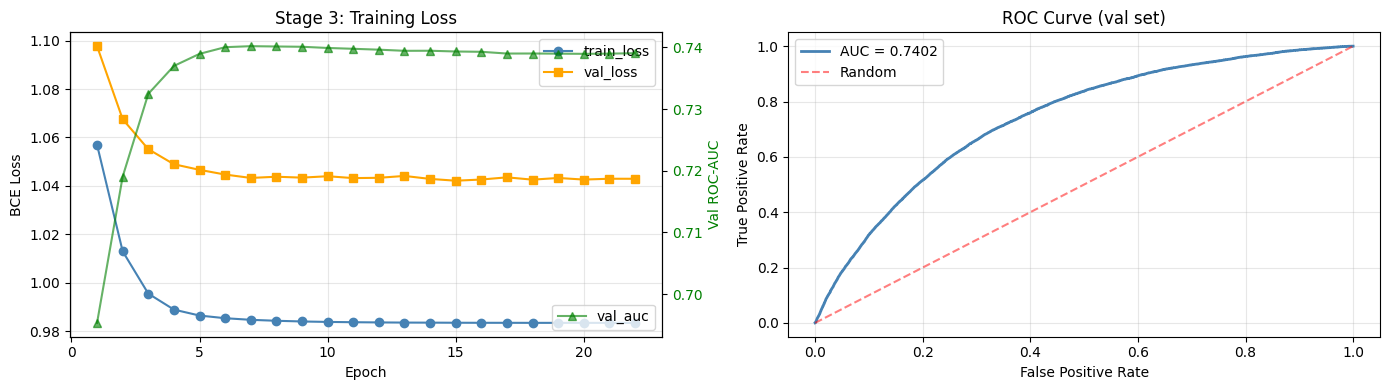


DIAGNOSTIC 2: Decision Block Weights — the interpretability moment

concept                  |     weight |  expected | sign ok?   | magnitude      
--------------------------------------------------------------------------------
  degradation_severity   |    +1.0731 |         + | ✓          | large          
  pace_decay_rate        |    -0.1885 |         + | ✗ MISMATCH | small          
  strategic_window       |    +1.1990 |         + | ✓          | large          
  track_position_risk    |    -0.2383 |         ? | ✓          | small          
  undercut_pressure      |    +1.6079 |         + | ✓          | large          
  endgame_proximity      |    -2.9945 |         - | ✓          | large          

  bias                                              | -0.6079

  Sign check: 5/6 concepts match expected direction

DIAGNOSTIC 3: Per-Concept Contribution to Logit (val set)

concept                  |       mean |        std |        max |        min
------------------------------

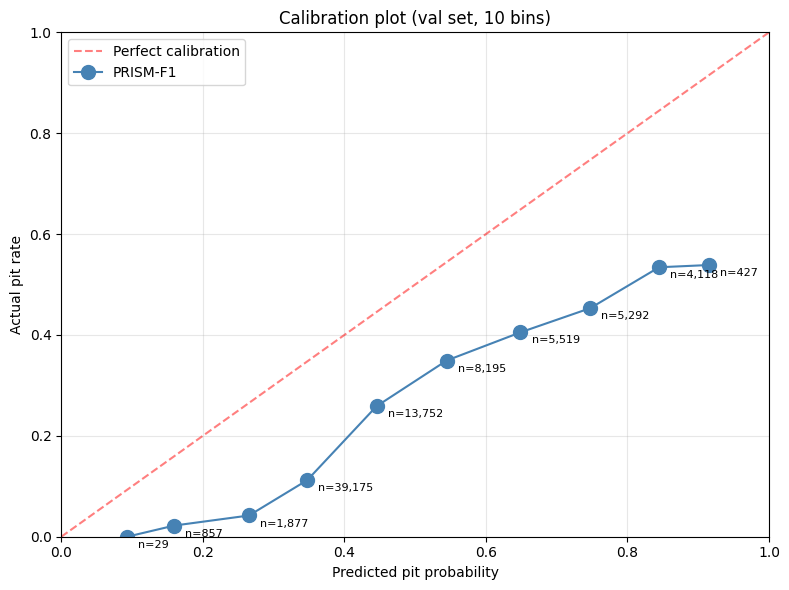


DIAGNOSTIC 5: Audit Trail Examples (the demo gold)

--- HIGH pit_prob (sample 29628) ---
Actual PitNextLap = 0
Predicted pit_prob = 0.9452

  concept                |    value |   × weight |   = contrib
  ------------------------------------------------------------
  degradation_severity   |   0.9119 |    +1.0731 |     +0.9785
  pace_decay_rate        |   0.0183 |    -0.1885 |     -0.0034
  strategic_window       |   0.7545 |    +1.1990 |     +0.9046
  track_position_risk    |   0.0607 |    -0.2383 |     -0.0145
  undercut_pressure      |   0.9888 |    +1.6079 |     +1.5898
  endgame_proximity      |   0.0000 |    -2.9945 |     -0.0001
  bias                   |          |            |     -0.6079
  ------------------------------------------------------------
  TOTAL LOGIT            |          |            |     +2.8470
  sigmoid(logit)         |          |            |      0.9452

--- MID pit_prob (sample 20690) ---
Actual PitNextLap = 0
Predicted pit_prob = 0.5000

  concept      

In [6]:
# Section 4 — Stage 3 Diagnostics

print("=" * 70)
print("STAGE 3 DIAGNOSTICS")
print("=" * 70)

# Load best checkpoint
ckpt3 = torch.load(CHECKPOINTS_DIR / 'stage3_decision_block.pt', weights_only=False)
decision_block.load_state_dict(ckpt3['decision_block_state_dict'])
decision_block.eval()

# Generate val-set predictions
all_probs, all_logits, all_concepts, all_targets = [], [], [], []
with torch.no_grad():
    for cb, pb in val_loader:
        cb = cb.to(DEVICE)
        pit_prob, logit = decision_block(cb)
        all_probs.append(pit_prob.cpu().numpy())
        all_logits.append(logit.cpu().numpy())
        all_concepts.append(cb.cpu().numpy())
        all_targets.append(pb.numpy())
val_probs = np.concatenate(all_probs)
val_logits = np.concatenate(all_logits)
val_concepts = np.concatenate(all_concepts)
val_targets = np.concatenate(all_targets)
print(f"Generated predictions for {len(val_probs):,} val samples")


# ── Diagnostic 1: Training curves + ROC
print("\n" + "=" * 70)
print("DIAGNOSTIC 1: Training Curves and ROC Curve")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: training curves
history = ckpt3['history']
ax1 = axes[0]
ax1.plot(history['epoch'], history['train_loss'], 'o-', label='train_loss', color='steelblue')
ax1.plot(history['epoch'], history['val_loss'], 's-', label='val_loss', color='orange')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('BCE Loss')
ax1.set_title('Stage 3: Training Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax1_twin = ax1.twinx()
ax1_twin.plot(history['epoch'], history['val_auc'], '^-', label='val_auc', color='green', alpha=0.6)
ax1_twin.set_ylabel('Val ROC-AUC', color='green')
ax1_twin.tick_params(axis='y', labelcolor='green')
ax1_twin.legend(loc='lower right')

# Right: ROC curve
fpr, tpr, _ = roc_curve(val_targets, val_probs)
axes[1].plot(fpr, tpr, label=f'AUC = {ckpt3["best_val_auc"]:.4f}', color='steelblue', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'r--', alpha=0.5, label='Random')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (val set)')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ── Diagnostic 2: Concept weights and bias
print("\n" + "=" * 70)
print("DIAGNOSTIC 2: Decision Block Weights — the interpretability moment")
print("=" * 70)

weights = decision_block.linear.weight[0].detach().cpu().numpy()
bias = decision_block.linear.bias.item()

# Expected signs (from domain knowledge / earlier analysis)
expected_signs = {
    'degradation_severity':    '+',
    'pace_decay_rate':         '+',
    'strategic_window':        '+',
    'track_position_risk':     '?',  # unclear from data
    'undercut_pressure':       '+',
    'endgame_proximity':       '-',
}

print(f"\n{'concept':<24s} | {'weight':>10s} | {'expected':>9s} | {'sign ok?':<10s} | {'magnitude':<15s}")
print("-" * 80)
sign_check = []
for j, name in enumerate(CONCEPT_NAMES):
    w = weights[j]
    expected = expected_signs[name]
    sign_match = (
        (expected == '+' and w > 0) or 
        (expected == '-' and w < 0) or 
        (expected == '?')
    )
    sign_check.append(sign_match)
    
    if abs(w) < 0.05:
        mag = "near zero"
    elif abs(w) < 0.3:
        mag = "small"
    elif abs(w) < 1.0:
        mag = "moderate"
    else:
        mag = "large"
    
    status = "✓" if sign_match else "✗ MISMATCH"
    print(f"  {name:<22s} | {w:>+10.4f} | {expected:>9s} | {status:<10s} | {mag:<15s}")

print(f"\n  bias                                              | {bias:>+.4f}")
print(f"\n  Sign check: {sum(sign_check)}/{len(sign_check)} concepts match expected direction")


# ── Diagnostic 3: Per-concept contribution distribution
print("\n" + "=" * 70)
print("DIAGNOSTIC 3: Per-Concept Contribution to Logit (val set)")
print("=" * 70)

# Contributions per sample: w_i * c_i for each concept
contributions = val_concepts * weights  # shape (N, 6)

print(f"\n{'concept':<24s} | {'mean':>10s} | {'std':>10s} | {'max':>10s} | {'min':>10s}")
print("-" * 75)
for j, name in enumerate(CONCEPT_NAMES):
    c = contributions[:, j]
    print(f"  {name:<22s} | {c.mean():>+10.4f} | {c.std():>10.4f} | {c.max():>+10.4f} | {c.min():>+10.4f}")

# Which concept contributes most to high-pit-prob predictions?
print(f"\nFor the top 10% highest-pit-prob predictions, average concept contribution:")
top10_mask = val_probs > np.quantile(val_probs, 0.9)
for j, name in enumerate(CONCEPT_NAMES):
    c_top = contributions[top10_mask, j].mean()
    print(f"  {name:<22s}: {c_top:>+.4f}")


# ── Diagnostic 4: Calibration plot
print("\n" + "=" * 70)
print("DIAGNOSTIC 4: Calibration Plot")
print("=" * 70)

# Bin predicted probabilities and compute observed pit rate per bin
n_bins = 10
bin_edges = np.linspace(0, 1, n_bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
observed_rates = []
expected_rates = []
counts = []
for i in range(n_bins):
    mask = (val_probs >= bin_edges[i]) & (val_probs < bin_edges[i+1])
    if i == n_bins - 1:
        mask = mask | (val_probs == 1.0)
    if mask.sum() > 0:
        observed_rates.append(val_targets[mask].mean())
        expected_rates.append(val_probs[mask].mean())
        counts.append(mask.sum())
    else:
        observed_rates.append(np.nan)
        expected_rates.append(bin_centers[i])
        counts.append(0)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], 'r--', alpha=0.5, label='Perfect calibration')
ax.plot(expected_rates, observed_rates, 'o-', markersize=10, color='steelblue', label='PRISM-F1')
for i, n in enumerate(counts):
    if n > 0:
        ax.annotate(f'n={n:,}', (expected_rates[i], observed_rates[i]), 
                    textcoords="offset points", xytext=(8, -8), fontsize=8)
ax.set_xlabel('Predicted pit probability'); ax.set_ylabel('Actual pit rate')
ax.set_title('Calibration plot (val set, 10 bins)')
ax.legend(); ax.grid(alpha=0.3)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


# ── Diagnostic 5: Audit trail for 3 example predictions
print("\n" + "=" * 70)
print("DIAGNOSTIC 5: Audit Trail Examples (the demo gold)")
print("=" * 70)

# Pick 3 examples: high-pit-prob, low-pit-prob, and one near 0.5
sample_high = np.argmax(val_probs)
sample_low = np.argmin(val_probs)
mid_target = 0.5
sample_mid = np.argmin(np.abs(val_probs - mid_target))

for sample_idx, label in [(sample_high, 'HIGH pit_prob'), 
                          (sample_mid, 'MID pit_prob'), 
                          (sample_low, 'LOW pit_prob')]:
    print(f"\n--- {label} (sample {sample_idx}) ---")
    print(f"Actual PitNextLap = {int(val_targets[sample_idx])}")
    print(f"Predicted pit_prob = {val_probs[sample_idx]:.4f}")
    print(f"\n  {'concept':<22s} | {'value':>8s} | {'× weight':>10s} | {'= contrib':>11s}")
    print(f"  {'-' * 60}")
    total = bias
    for j, name in enumerate(CONCEPT_NAMES):
        c_val = val_concepts[sample_idx, j]
        w = weights[j]
        contrib = c_val * w
        total += contrib
        print(f"  {name:<22s} | {c_val:>8.4f} | {w:>+10.4f} | {contrib:>+11.4f}")
    print(f"  {'bias':<22s} | {'':<8s} | {'':<10s} | {bias:>+11.4f}")
    print(f"  {'-' * 60}")
    print(f"  {'TOTAL LOGIT':<22s} | {'':<8s} | {'':<10s} | {total:>+11.4f}")
    print(f"  {'sigmoid(logit)':<22s} | {'':<8s} | {'':<10s} | {1/(1+np.exp(-total)):>11.4f}")